<a href="https://colab.research.google.com/github/landinh0804/ai4g-portfolio-Dylan/blob/main/Term%201/Week%205/homework/Week5_Workshop_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI for Good — Minor ADSAI
## Week 5: Machine Learning Basics

For four weeks **you** wrote every rule. This week the computer writes the rules — by learning from examples. You will train and test your first real machine-learning models with **scikit-learn**, the standard Python ML toolkit, on a **real medical dataset**.

**Theme of the week:** *AI that assists, never replaces*. We use a real breast-cancer screening dataset to ask the question that matters more than accuracy: **when a model is wrong, who gets hurt?**

> **Setup:** this week needs `scikit-learn` (already installed with Anaconda). Everything runs offline on datasets that ship with scikit-learn — no downloads.
> **Last section (16:45):** Friday's tool, done properly — the data-science recipe on real, messy data. It downloads one small file (the Titanic passenger list); `titanic.csv` next to this notebook is the no-wifi backup.

---

### 🧠 First: what *is* machine learning?

Until now, **you** wrote every rule by hand:

```python
if score >= 55:
    print("pass")
```

That works when *you* know the rule. But what is the rule for *"is this tumour dangerous?"* or *"is this email spam?"* Nobody can write that rule by hand — there are too many tiny factors.

**Machine learning flips it around.** Instead of writing the rule, you show the computer many **examples that already have the answer**, and it finds the pattern itself:

- **features** (`X`) — the measurements that describe each example (tumour size, texture, …)
- **label** (`y`) — the known answer for each example (`malignant` or `benign`)

The model **learns** the relationship `X → y`, then **predicts** `y` for new examples it has never seen. This is called **supervised learning**.

#### Two golden rules
1. **Split your data.** Train on one part, then *test* on another part the model never saw — like studying from practice questions, then sitting a real exam. Testing on the training data is cheating (the model could just memorise).
2. **Garbage in, garbage out.** The model only knows the examples you gave it. *(Remember Week 3 & 4: who is missing from the data?)* A model trained on one hospital's patients may fail badly on another's.

Every scikit-learn model uses the **same four steps**, no matter which algorithm:

```python
model = SomeModel()          # 1. choose
model.fit(X_train, y_train)  # 2. learn from examples
preds = model.predict(X_test)# 3. predict on unseen data
accuracy_score(y_test, preds)# 4. check
```

---
## Learning Wave 1 — The Machine Learning Workflow (KNN)

Your first algorithm is the most intuitive one: **K-Nearest Neighbours (KNN)**.

> **Intuition:** to decide what a new patient is, look at the **k** most similar patients you already know the answer for, and take a **majority vote**. *"You are like your closest neighbours."* If 4 of the 5 nearest patients had benign tumours, KNN predicts benign.

### Exercise 1: Train your first model
⏱ **15 minutes** | Slide 7

**Steps:**
1. Load the real dataset: `from sklearn.datasets import load_breast_cancer`. Get `X = data.data` and `y = data.target`.
2. Explore: how many patients? how many measurements per patient? What are the class names (`data.target_names`)?
3. Split into train/test with `train_test_split(X, y, test_size=0.25, random_state=42)`.
4. Create a `KNeighborsClassifier(n_neighbors=5)`, `fit()` it on the training data.
5. `predict()` on the test data and print the `accuracy_score`.
6. Print the prediction vs the real answer for the first test patient.

In [1]:
# Exercise 1: Train your first model
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1 & 2. Load the data and explore it (X = data.data, y = data.target)
data = load_breast_cancer()
X = data.data
y = data.target
print("Patients:", X.shape[0])
print("Measurements per patient:", X.shape[1])
print("Classes:", list(data.target_names), "(0 = malignant, 1 = benign)")

# 3. Split into train and test (test_size=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print("Train:", len(X_train), "| Test:", len(X_test))

# 4. Create KNeighborsClassifier(n_neighbors=5) and fit it on the training data
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# 5. Predict on the test data and print the accuracy
predictions = knn.predict(X_test)
print("KNN test accuracy:", round(accuracy_score(y_test, predictions), 3))

# 6. Print prediction vs actual for the first test patient
print("First test patient -> predicted:", data.target_names[predictions[0]],
      "| actual:", data.target_names[y_test[0]])

Patients: 569
Measurements per patient: 30
Classes: [np.str_('malignant'), np.str_('benign')] (0 = malignant, 1 = benign)
Train: 426 | Test: 143
KNN test accuracy: 0.965
First test patient -> predicted: benign | actual: benign


---
## Learning Wave 2 — Different Models, Same Workflow

The beauty of scikit-learn: **swap the model, keep the four steps.** Let's try two more famous algorithms on the *same* split and see which wins.

- **Logistic Regression** — draws the best boundary line between the two classes (despite the name, it *classifies*).
- **Decision Tree** — asks a series of yes/no questions (`is texture > 20?`). You can read it like a flowchart, which makes it easy to explain to a doctor.

You will also meet the central danger of ML: **overfitting** — a model that *memorises* the training data and then fails on new data. The tell-tale sign is high **train** accuracy but low **test** accuracy.

### Exercise 2: Compare three models
⏱ **15 minutes** | Slide 10

**Steps:**
1. Train a `LogisticRegression(max_iter=5000)` on the same split; print its test accuracy.
2. Train a `DecisionTreeClassifier(max_depth=3, random_state=42)`; print its test accuracy.
3. Now train a tree with **no depth limit** and compare its **train** accuracy to its **test** accuracy — what do you see?
4. A tree is readable: use `feature_importances_` to print which measurement it relies on most.

In [2]:
# Exercise 2: Compare three models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import numpy as np

# 1. Train LogisticRegression(max_iter=5000) and print test accuracy
logreg = LogisticRegression(max_iter=5000)
logreg.fit(X_train, y_train)
print("Logistic regression test accuracy:", round(accuracy_score(y_test, logreg.predict(X_test)), 3))

# 2. Train DecisionTreeClassifier(max_depth=3, random_state=42) and print test accuracy
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)
print("Decision tree (depth 3) test accuracy:", round(accuracy_score(y_test, tree.predict(X_test)), 3))

# 3. Train a tree with NO depth limit; compare its TRAIN vs TEST accuracy (overfitting!)
deep_tree = DecisionTreeClassifier(random_state=42)
deep_tree.fit(X_train, y_train)
print("Deep tree TRAIN accuracy:", round(accuracy_score(y_train, deep_tree.predict(X_train)), 3))
print("Deep tree TEST accuracy: ", round(accuracy_score(y_test, deep_tree.predict(X_test)), 3))
print("-> 100% on data it has seen, lower on new data: it memorised the training set (overfitting).")

# 4. Print the measurement the shallow tree relies on most (feature_importances_)
top = np.argmax(tree.feature_importances_)
print("The depth-3 tree relies most on:", data.feature_names[top],
      "(importance", round(tree.feature_importances_[top], 2), ")")

Logistic regression test accuracy: 0.965
Decision tree (depth 3) test accuracy: 0.958
Deep tree TRAIN accuracy: 1.0
Deep tree TEST accuracy:  0.951
-> 100% on data it has seen, lower on new data: it memorised the training set (overfitting).
The depth-3 tree relies most on: mean concave points (importance 0.79 )


---
## Learning Wave 3 — Accuracy Lies: Looking at the Errors

"95% accurate" sounds great. But **accuracy treats every mistake as equal — and in the real world, they are not.** Telling a healthy person they might be sick (a *false alarm*) is upsetting. Telling a sick person they are healthy (a *dangerous miss*) can be fatal.

A **confusion matrix** breaks the predictions into four boxes so you can see *which kind* of mistake the model makes:

|  | predicted malignant | predicted benign |
|---|---|---|
| **actual malignant** | correct | ⚠️ dangerous miss |
| **actual benign** | false alarm | correct |

### Exercise 3: Read the confusion matrix
⏱ **20 minutes** (incl. reflection) | Slide 13

**Steps:**
1. Get `predictions` from your KNN model and build `confusion_matrix(y_test, predictions)`.
2. Print it with labels so you can tell the four boxes apart. *(Reminder: 0 = malignant, 1 = benign.)*
3. Pull out the number of **dangerous misses** (malignant predicted benign) and **false alarms** (benign predicted malignant).
4. **Reflection** (markdown cell below).

In [3]:
# Exercise 3: Read the confusion matrix
from sklearn.metrics import confusion_matrix

# 1. Build the confusion matrix from your KNN predictions on the test set
cm = confusion_matrix(y_test, predictions)

# 2. Print it clearly (remember: 0 = malignant, 1 = benign)
print("                     predicted malignant | predicted benign")
print("actual malignant   :", str(cm[0][0]).rjust(10), "|", str(cm[0][1]).rjust(10))
print("actual benign      :", str(cm[1][0]).rjust(10), "|", str(cm[1][1]).rjust(10))

# 3. Print the number of dangerous misses and false alarms
dangerous_misses = cm[0][1]   # malignant, but predicted benign
false_alarms = cm[1][0]       # benign, but predicted malignant
print("\nDangerous misses (cancer sent home):", dangerous_misses)
print("False alarms (healthy person worried):", false_alarms)

                     predicted malignant | predicted benign
actual malignant   :         50 |          4
actual benign      :          1 |         88

Dangerous misses (cancer sent home): 4
False alarms (healthy person worried): 1


#### ✍️ Reflection
**In screening, which mistake is worse — a dangerous miss or a false alarm? Should a medical model be tuned to avoid one more than the other? And who should make that decision — the programmer, the doctor, or the patient?**

> In screening, the **dangerous miss** is worse. My KNN sent **4 of the 54 malignant tumours** home as "benign". For those patients the cancer keeps growing untreated. The **1 false alarm** means a healthy person gets worried and needs an extra test, which is unpleasant but fixable. So a screening model should be tuned to **miss as few cancers as possible (high recall for malignant)**, even if that causes more false alarms.
> The programmer shouldn't make that trade-off alone. **Doctors** know what a false alarm costs (extra scans, biopsies, anxiety) and what a miss costs. **Patients** should have a say in how much risk is acceptable. The programmer's job is to make the trade-off visible, for example with the confusion matrix, and the model should only *assist* the doctor, never give the final diagnosis.

---
## Big Individual Assignment — 135 minutes

### 🤖 Build & Evaluate Your Own Classifier

**Goal:** Take a **real dataset**, train one or more models, and **evaluate them honestly** — then judge which errors matter. This is the full ML workflow, start to finish, on your own.

> **Open-ended, like last week — you make the choices.** Which dataset, which model(s), which hyperparameter to tune — that is up to you. What is fixed is that you must run the *complete* workflow you learned today and reason about the errors.

#### ✅ Your notebook **must** include all of these (this week's skills):
- Load a **real** dataset and split it with `train_test_split`
- Train at least **two different models** (KNN / Logistic Regression / Decision Tree) **or** one model tuned across several hyperparameter values
- Report **test accuracy** for each, and clearly state which performed best
- Print and interpret a **confusion matrix** for your best model
- A short written conclusion: **which kind of error matters most for this dataset, and why?**

#### 📊 Pick one real dataset (all ship with scikit-learn — no downloads):
- `load_breast_cancer()` — tumour screening (health)
- `load_wine()` — wine quality control from chemical measurements
- `load_iris()` — the classic: classify flower species from petal/sepal sizes

#### 🌟 Bonus (for fast finishers):
- Tune KNN across `k = 1, 3, 5, …, 25` and **plot** accuracy vs k with `matplotlib`.
- Add a second metric: `from sklearn.metrics import classification_report` (precision & recall).
- Scale the features with `StandardScaler` and see if KNN improves.

#### 💡 Tips:
1. Write **one helper function** `evaluate(model, ...)` that fits, predicts, and prints accuracy — then call it for each model. Less copy-paste, fewer bugs.
2. Keep `random_state=42` everywhere so your results are reproducible.
3. If `LogisticRegression` warns about convergence, raise `max_iter` (e.g. `max_iter=5000`).

#### ✍️ Reflection (markdown cell below).

=== Breast cancer ===
Samples: 569 | features: 30 | classes: [np.str_('malignant'), np.str_('benign')]
KNN (k=5)                        train 0.946 | test 0.93
KNN (k=5) + StandardScaler       train 0.969 | test 0.979
Logistic regression + scaler     train 0.988 | test 0.986
Decision tree (depth 3)          train 0.977 | test 0.944


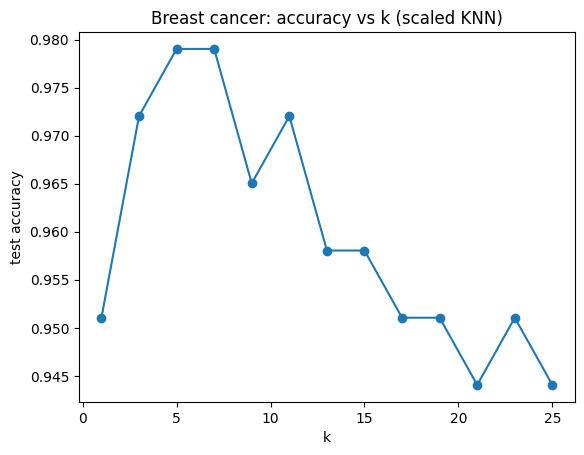


Best model: Logistic regression + scaler with test accuracy 0.986
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        53
      benign       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



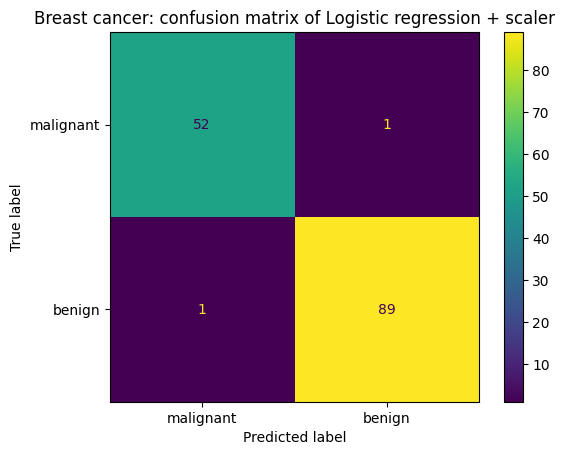

In [4]:
# Big Assignment: Build & Evaluate Your Own Classifier
# Dataset 1: breast cancer screening (569 patients, 30 measurements, 0 = malignant, 1 = benign)
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

def evaluate(name, model, X_train, X_test, y_train, y_test):
    """Fit, predict and print train + test accuracy. Returns the test accuracy."""
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    print(name.ljust(32), "train", round(train_acc, 3), "| test", round(test_acc, 3))
    return test_acc

def run_workflow(X, y, class_names, title):
    """The full workflow on one dataset: split, compare models, tune KNN, confusion matrix of the best."""
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
    print("===", title, "===")
    print("Samples:", len(X), "| features:", X.shape[1], "| classes:", list(class_names))
    models = {
        "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
        "KNN (k=5) + StandardScaler": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
        "Logistic regression + scaler": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
        "Decision tree (depth 3)": DecisionTreeClassifier(max_depth=3, random_state=42),
    }
    results = {}
    for name, model in models.items():
        results[name] = evaluate(name, model, X_train, X_test, y_train, y_test)

    # Bonus: tune k for scaled KNN and plot it
    ks = list(range(1, 26, 2))
    k_acc = []
    for k in ks:
        m = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k)).fit(X_train, y_train)
        k_acc.append(accuracy_score(y_test, m.predict(X_test)))
    plt.plot(ks, k_acc, marker="o")
    plt.xlabel("k"); plt.ylabel("test accuracy"); plt.title(title + ": accuracy vs k (scaled KNN)")
    plt.show()

    best_name = max(results, key=results.get)
    best_model = models[best_name]
    print("\nBest model:", best_name, "with test accuracy", round(results[best_name], 3))
    print(classification_report(y_test, best_model.predict(X_test), target_names=class_names))
    ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, display_labels=class_names)
    plt.title(title + ": confusion matrix of " + best_name)
    plt.show()
    return results

cancer = load_breast_cancer()
cancer_results = run_workflow(cancer.data, cancer.target, cancer.target_names, "Breast cancer")

### 🏠 Homework — the same workflow on a second dataset (wine)
The wine dataset: 178 wines from 3 cultivars (grape growers), 13 chemical measurements each. Same function, same settings, nothing changed.

=== Wine ===
Samples: 178 | features: 13 | classes: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]
KNN (k=5)                        train 0.789 | test 0.778
KNN (k=5) + StandardScaler       train 0.992 | test 0.933
Logistic regression + scaler     train 1.0 | test 1.0
Decision tree (depth 3)          train 0.992 | test 0.956


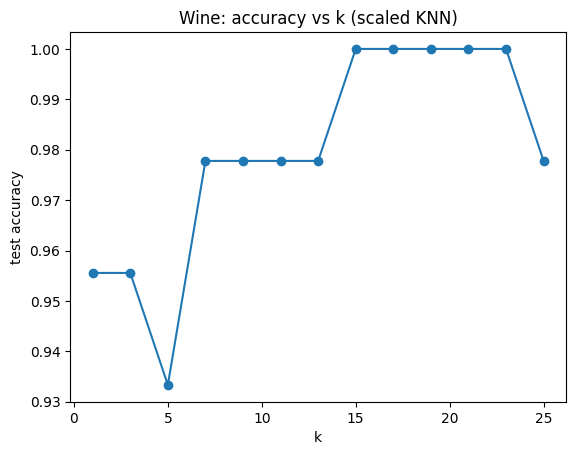


Best model: Logistic regression + scaler with test accuracy 1.0
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        15
     class_1       1.00      1.00      1.00        18
     class_2       1.00      1.00      1.00        12

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



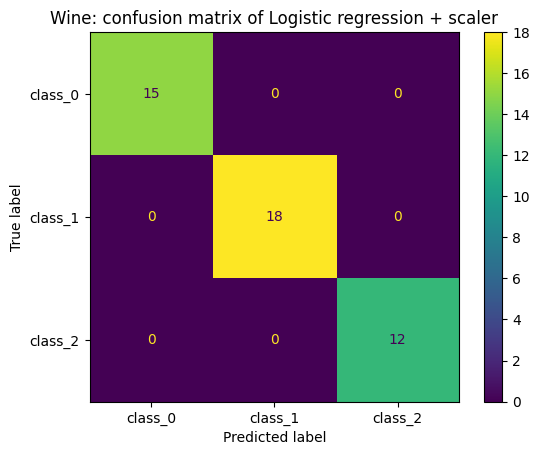


Side by side (test accuracy):
KNN (k=5)                        cancer 0.93 | wine 0.778
KNN (k=5) + StandardScaler       cancer 0.979 | wine 0.933
Logistic regression + scaler     cancer 0.986 | wine 1.0
Decision tree (depth 3)          cancer 0.944 | wine 0.956


In [5]:
from sklearn.datasets import load_wine
wine = load_wine()
wine_results = run_workflow(wine.data, wine.target, wine.target_names, "Wine")

print("\nSide by side (test accuracy):")
for name in cancer_results:
    print(name.ljust(32), "cancer", round(cancer_results[name], 3), "| wine", round(wine_results[name], 3))

#### Conclusion & comparing the two datasets

| Model | Breast cancer (test acc.) | Wine (test acc.) |
|---|---|---|
| KNN (k=5), unscaled | 0.930 | 0.778 |
| KNN (k=5) + StandardScaler | 0.979 | 0.933 |
| Logistic regression + scaler | **0.986** | **1.000** |
| Decision tree (depth 3) | 0.944 | 0.956 |

**Best model on both:** logistic regression with scaled features. On breast cancer its confusion matrix shows **1 missed cancer and 1 false alarm** out of 143 test patients (recall for malignant 0.98).

**Which error matters most?** For **breast cancer**, the *dangerous miss* (malignant predicted benign), because a missed cancer can cost a life while a false alarm "only" costs an extra test. So I would judge these models on **recall for malignant**, not on accuracy. For **wine**, all errors are roughly equally bad: a wrong cultivar label is a quality-control or pricing mistake, and nobody gets hurt. So plain accuracy is a fair score there.

**What the comparison shows:**
1. **Scaling matters most for KNN.** Without scaling, KNN drops from 0.93 to **0.78 on wine**, because wine's measurements have very different ranges (proline is in the hundreds or thousands, other features below 1), so one feature dominates the distance. On breast cancer the effect is smaller (0.93 → 0.98).
2. **The same workflow transfers.** The same function gave a sensible ranking on both datasets, and logistic regression won both times.
3. **A perfect score is a warning, not a victory.** 100% on wine comes from only **45 test wines**, so one more mistake would change it to 97.8%. The dataset is small, clean and easy to separate. Real wine-lab data (other harvests, other machines) would not score this well.

#### 🌍 Bonus Reflection
**A model is only as good as the data it learned from. The breast-cancer dataset comes from one set of patients at one place and time. What could go wrong if a hospital deployed your model on a very different population — and whose responsibility is it to check?**

> This dataset comes from one hospital in Wisconsin (USA), from the early 1990s, measured with one imaging set-up. Another hospital might have patients of different ages or ethnic backgrounds, younger women with denser breast tissue, or a different scanner and lab procedure. Then the measurements shift, and the model's 98% accuracy no longer means anything. It could quietly miss far more cancers in exactly the group that was missing from the training data, and nobody would notice, because the model never says "I haven't seen patients like you".
> Checking this is a **shared responsibility**. The developers must document where the data came from and who it does and doesn't cover. The **hospital deploying it** must test it on its own patients, per group, *before* using it and keep monitoring it. Regulators must require that evidence. A doctor stays responsible for every diagnosis.

---
## 5 Things to Remember

1. **ML learns rules from examples** — give it features `X` and labels `y`, and it figures out `X → y` instead of you writing the rule.
2. **Always split train/test** — score the model on data it never saw, or you are just measuring memorisation.
3. **Same four steps for every model** — `choose → fit → predict → score`. Swapping KNN for a tree is a one-line change.
4. **Overfitting = great on train, poor on test** — a model that memorises has not really learned. Simpler models often generalise better.
5. **Accuracy hides which errors you make** — read the confusion matrix, and ask *who is harmed* by a false negative vs a false positive. A human stays responsible.

---
**Next week:** Language Models — teaching a computer to classify and understand text, building straight on Week 4's bag-of-words and this week's classifiers.  
**Homework:** Run the wrap-up section (last section) to the end and do its four *Your turn* cells · Finish your classifier notebook · Try your workflow on a second dataset and write one paragraph comparing the results.  
**Friday:** Hackathon 5 — the tool is **scikit-learn**, the same one as today, done properly (see the wrap-up section below). You find out the SDG on the day.

---
## Wrap-up — Friday's tool: scikit-learn, done properly

*Slides of `Week5_Wrapup.pptx`. The tool is the one you used all day. Which SDG it has to serve, you find out on Friday.*

### 🧠 Today's data was too clean

The breast-cancer data was a gift: only numbers, no gaps, already tidy. **Real data is never like that.** It has empty cells, words instead of numbers, weird values, and sometimes a column that secretly contains the answer.

On Friday you work with data *you* find yourself. So here is the honest truth about machine learning:

> **The model is one line of code. Everything around it is the actual job.**

This section walks you through the **proper recipe** — eight steps — on real, messy data. Every step is small. Run the cells in order, read the output, and do the four *Your turn* cells. On Friday you copy this recipe and swap in your own data.

| Step | The question it answers | The key line |
|---|---|---|
| 1. Look before you touch | What is in this table, and what is wrong with it? | `df.isna().sum()` |
| 2. Split first | Can I lock away an honest exam before I do anything else? | `train_test_split(..., stratify=y)` |
| 3. Set a baseline | What score does a lazy model get? | `DummyClassifier()` |
| 4. Clean inside a Pipeline | How do I fix gaps, words and scales without cheating? | `Pipeline([...])` |
| 5. Pick your scoreboard | Which mistake is worse for the people involved? | `scoring="f1"` |
| 6. Tune with practice exams | Which settings work best — without touching the exam? | `GridSearchCV(...)` |
| 7. The final exam, once | Which model wins, honestly? | `model.predict(X_test)` |
| 8. Check the groups, then use it | Does it work equally well for everyone? | `predict_proba(...)` |

### Our messy example: the Titanic

891 real passengers of the Titanic (1912) and one question: **who survived?**

---
### Step 1 — Look before you touch

Real data usually arrives as a **CSV file**: a spreadsheet saved as plain text. We read it with **pandas**, Python's spreadsheet library (it comes with Anaconda). A pandas **DataFrame** is simply a table: rows are passengers, columns are facts about them — think of the list of dictionaries from Week 3, but printed nicely.

Four new lines to remember:

| Line | What it does |
|---|---|
| `pd.read_csv(...)` | load a CSV file (or a link to one) into a table |
| `df.head()` | show the first 5 rows |
| `df.shape` | (number of rows, number of columns) |
| `df["age"]` | one column, like a dictionary lookup |

In [6]:
# Step 1a — Load the data and look at it
import pandas as pd

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
df = pd.read_csv(url)   # no wifi? use: df = pd.read_csv("titanic.csv")  (the file next to this notebook)

print("Rows, columns:", df.shape)
df.head()

Rows, columns: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Now the **health check**. Before you train anything, answer four questions — every one of them has a problem hiding in this table:

1. **Are there gaps?** `df.isna().sum()` counts the empty cells per column.
2. **Is the answer balanced?** `value_counts(normalize=True)` shows what share of passengers survived.
3. **Are there weird values?** `describe()` shows min and max — look for things that cannot be true.
4. **Are there duplicate rows?** `duplicated().sum()`.

In [7]:
# Step 1b — The health check
print("1. Empty cells per column:")
print(df.isna().sum())

print("\n2. Share of survivors (1) and non-survivors (0):")
print(df["survived"].value_counts(normalize=True).round(2))

print("\n3. Ticket prices (fare): lowest, highest, and how many paid 0:")
print("min", df["fare"].min(), "| max", df["fare"].max(), "| fare == 0:", (df["fare"] == 0).sum())

print("\n4. Duplicate rows:", df.duplicated().sum())

1. Empty cells per column:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

2. Share of survivors (1) and non-survivors (0):
survived
0    0.62
1    0.38
Name: proportion, dtype: float64

3. Ticket prices (fare): lowest, highest, and how many paid 0:
min 0.0 | max 512.3292 | fare == 0: 15

4. Duplicate rows: 107


**What the health check tells us — in plain words:**

- **Gaps:** 177 passengers have no `age`, 2 have no `embarked` (port), and `deck` is empty for 688 of 891 people. Age we can fill in; `deck` is mostly empty, so we drop it.
- **Unbalanced answer:** only 38 % survived. So a lazy model that always says *"did not survive"* is already right 62 % of the time. Remember that number — it comes back in step 3.
- **Weird values:** 15 people paid a fare of 0. Crew? Free tickets? A missing value in disguise? You cannot tell from the numbers — **you have to go and find out**, and write down what you decided.
- **Duplicates:** 107 rows look identical. Here they are different passengers who happen to share a class, sex, age and ticket price, so we keep them. In your data, check: is it the same person twice? Then remove one.

#### ⚠️ The cheat column
Some columns **contain the answer** in disguise. A model that gets to see one will score (almost) 100 % — and be completely useless, because in real life you do not have that column when you need the prediction. This is called **leakage**. Rule of thumb: **a score that looks too good to be true is a bug, not a victory.**

#### 🧩 Your turn 1 — find the cheat column
Look at `df.head()` again. One column says the same thing as `survived`, just in words. Find it. Then check: which other columns are just copies of another column (the same fact twice)? Write your answer as a comment in the cell below.

In [8]:
# Your turn 1 — find the cheat column
print(df[["survived", "alive"]].drop_duplicates())
print(df[["pclass", "class"]].drop_duplicates().sort_values("pclass"))
print(df[["embarked", "embark_town"]].drop_duplicates())

# ANSWER:
# - The cheat column is "alive": it is "yes" exactly when survived == 1 and "no" when survived == 0.
#   It IS the answer in words, so a model that sees it scores ~100% and is useless (leakage).
# - Copies of another column (the same fact twice):
#     "class"       = "pclass" in words (First/Second/Third = 1/2/3)
#     "embark_town" = "embarked" in words (Southampton/Cherbourg/Queenstown = S/C/Q)
#     "who" and "adult_male" are built from "sex" + "age" (man/woman/child)
#     "alone" is built from "sibsp" + "parch" (True when both are 0)
# - "deck" is mostly empty (688 of 891), so we leave it out.

   survived alive
0         0    no
1         1   yes
   pclass   class
1       1   First
9       2  Second
0       3   Third
   embarked  embark_town
0         S  Southampton
1         C    Cherbourg
5         Q   Queenstown
61      NaN          NaN


Now we choose **X** (the facts we may use) and **y** (the answer). We keep the original columns and leave out the cheat column, the copies, and `deck`.

In [9]:
# Step 1c — Choose X (the facts) and y (the answer)
features = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
X = df[features]
y = df["survived"]

number_columns = ["pclass", "age", "sibsp", "parch", "fare"]
word_columns = ["sex", "embarked"]
print("X:", X.shape, "| y:", y.shape)
X.head()

X: (891, 7) | y: (891,)


,pclass,sex,age,sibsp,parch,fare,embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


---
### Step 2 — Split first: the sealed envelope

Today you split right before training. With real data you split **even earlier — before you clean, fill in or tune anything.** Think of the test set as an exam in a **sealed envelope**: you put it in a drawer now and open it **once**, at the very end. Everything you decide — how to fill gaps, which settings to use — you decide without looking inside.

One new word: **`stratify=y`**. It makes sure both halves get the same share of survivors (38 %). Without it, bad luck could put most survivors in one half. Always use it for classification.

In [10]:
# Step 2 — Split first, with the same mix of survivors in both parts
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print("Train:", len(X_train), "passengers | Test (the sealed envelope):", len(X_test), "passengers")
print("Survivors in train:", round(y_train.mean(), 2), "| in test:", round(y_test.mean(), 2))

Train: 712 passengers | Test (the sealed envelope): 179 passengers
Survivors in train: 0.38 | in test: 0.39


---
### Step 3 — Set a baseline: the lazy model

Before you celebrate a score, ask: **what would a lazy model get?** scikit-learn has one: the `DummyClassifier` always predicts the most common answer. It learns nothing. Every real model has to beat it — otherwise it is not worth building.

In [11]:
# Step 3 — The lazy model
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, recall_score

lazy = DummyClassifier(strategy="most_frequent")   # always says the most common answer: 0
lazy.fit(X_train, y_train)
lazy_predictions = lazy.predict(X_test)

print("Lazy model accuracy:", round(accuracy_score(y_test, lazy_predictions), 2))
print("Survivors it found:", round(recall_score(y_test, lazy_predictions), 2))

Lazy model accuracy: 0.61
Survivors it found: 0.0


**61 % accuracy without learning anything — and it finds zero survivors.** That is why accuracy is dangerous on unbalanced data, and why step 5 picks a better scoreboard. (We are allowed to score the lazy model on the test set here: it learned nothing, so there is nothing to cheat with. For real models we wait until step 7.)

---
### Step 4 — Clean inside a Pipeline

A model only eats **numbers**, with **no gaps**, and — for KNN and logistic regression — **on the same scale**. So cleaning has three jobs:

| Job | Problem | The fix | Tool |
|---|---|---|---|
| **Fill the gaps** | 177 ages are empty | fill in the middle value (median) of the *training* passengers | `SimpleImputer` |
| **Turn words into numbers** | `sex` is `"male"`/`"female"` | one yes/no column per word: `sex_female`, `sex_male` | `OneHotEncoder` |
| **Put numbers on the same scale** | `fare` goes from 0 to 512, `sibsp` from 0 to 8 | shift every column so that it is centred on 0 with a similar spread | `StandardScaler` |

**Why the same scale?** KNN measures **distance** between passengers. A difference of 50 in fare would count 50 times more than a difference of 1 sibling — not because fare matters more, but because its numbers are bigger. Scaling makes every column speak equally loud. (Trees do not care about scale, but scaling does not hurt them.)

#### The Pipeline: a recipe card
A **Pipeline** glues the cleaning steps and the model together into one object. You call `fit` once, and it does everything in order. The big win: when you `fit` a Pipeline, it learns the median age and the scale **from the training data only**, and then applies exactly those numbers to the test data. That is how you avoid cheating without thinking about it.

```python
# ❌ WRONG — peeks in the envelope: the median and the scale are computed with the test passengers included
X_all = StandardScaler().fit_transform(X_filled)
X_train, X_test, ... = train_test_split(X_all, ...)

# ✅ RIGHT — split first, and let the Pipeline learn everything from the training part only
X_train, X_test, ... = train_test_split(X, ...)
model = Pipeline([("prep", prep), ("model", KNeighborsClassifier())])
model.fit(X_train, y_train)
```

In [12]:
# Step 4 — The cleaning recipe card
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numbers: fill the gaps with the median, then put them on the same scale
number_steps = Pipeline([
    ("fill", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

# Words: fill the gaps with the most common word, then one yes/no column per word
word_steps = Pipeline([
    ("fill", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

# The ColumnTransformer sends each column to the right recipe
prep = ColumnTransformer([
    ("numbers", number_steps, number_columns),
    ("words", word_steps, word_columns),
])

# Peek at what the cleaning does to the first 3 training passengers
# (fitted on the training data only — that is allowed)
cleaned = prep.fit_transform(X_train)
print("Before:", X_train.shape, "-> after:", cleaned.shape, "(sex and embarked became yes/no columns)")
print(prep.get_feature_names_out())
print(cleaned[:3].round(2))

Before: (712, 7) -> after: (712, 10) (sex and embarked became yes/no columns)
['numbers__pclass' 'numbers__age' 'numbers__sibsp' 'numbers__parch'
 'numbers__fare' 'words__sex_female' 'words__sex_male' 'words__embarked_C'
 'words__embarked_Q' 'words__embarked_S']
[[ 0.83 -0.08 -0.47 -0.47  0.51  0.    1.    0.    0.    1.  ]
 [-0.37 -0.08 -0.47 -0.47 -0.66  0.    1.    0.    0.    1.  ]
 [-1.57 -0.08 -0.47 -0.47  3.96  0.    1.    0.    0.    1.  ]]


Now glue the recipe card to a model. From here on, **a model = the cleaning + the algorithm**, in one object:

In [13]:
# A full Pipeline: cleaning + model, in one object
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline([
    ("prep", prep),
    ("model", KNeighborsClassifier(n_neighbors=5)),
])
knn_pipeline.fit(X_train, y_train)     # fills, encodes, scales and trains — on training data only
print("Trained! The steps inside:", [name for name, step in knn_pipeline.steps])

Trained! The steps inside: ['prep', 'model']


---
### Step 5 — Pick your scoreboard *before* you play

The lazy model showed that accuracy can lie. So choose what "good" means **before** you train — otherwise you are tempted to pick whichever number looks best afterwards. You already know the confusion matrix; these three scores are just questions about it:

| Score | The question in plain words | Care about it when… |
|---|---|---|
| **Recall** | Of all the people who *really* are "yes", how many did we find? | a **miss** is the worst mistake (a sick person sent home) |
| **Precision** | Of everyone we *said* "yes" to, how many really were? | a **false alarm** is the worst mistake (an innocent person flagged) |
| **F1** | a balance of recall and precision in one number | both mistakes matter |

**Example:** 100 passengers, 40 survived. Your model says "survived" to 30 people, and 24 of them really did.
- Recall = 24 / 40 = **0.60** — it found 60 % of the survivors.
- Precision = 24 / 30 = **0.80** — when it says "survived", it is right 80 % of the time.

For the Titanic demo we use **F1**. On Friday you choose, and you explain why: **which mistake hurts the people your model is about more?** That is not a coding question — it is the most important decision in the notebook.

---
### Step 6 — Tune with practice exams (cross-validation)

`n_neighbors=5` was a guess. How do we find a better value **without opening the envelope?** We make **practice exams** out of the training data:

```
training data, cut into 5 parts:   [ 1 ][ 2 ][ 3 ][ 4 ][ 5 ]
round 1:  practise on 2-5, test on 1
round 2:  practise on 1,3,4,5, test on 2
... five rounds, every part is the practice exam once
→ 5 scores. Their average tells you how good a setting is; their spread tells you how much luck is in it.
```

This is **cross-validation**. `cross_val_score` does all five rounds in one line. `StratifiedKFold` cuts the parts with the same share of survivors in each (the `stratify` idea again), and a fixed `random_state` makes sure every model gets **exactly the same practice exams** — otherwise the comparison is not fair.

In [14]:
# Step 6a — Five practice exams for one setting
from sklearn.model_selection import cross_val_score, StratifiedKFold

practice_exams = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(knn_pipeline, X_train, y_train, cv=practice_exams, scoring="f1")
print("The 5 practice-exam scores:", scores.round(2))
print("Average:", round(scores.mean(), 3), "| spread (std):", round(scores.std(), 3))

The 5 practice-exam scores: [0.73 0.73 0.73 0.69 0.71]
Average: 0.72 | spread (std): 0.017


**Proof that scaling matters.** Same KNN, same practice exams — once with the scaler and once without:

In [15]:
# Step 6b — KNN with and without the scaler
no_scale_prep = ColumnTransformer([
    ("numbers", SimpleImputer(strategy="median"), number_columns),   # filled, but NOT scaled
    ("words", word_steps, word_columns),
])
knn_no_scale = Pipeline([("prep", no_scale_prep), ("model", KNeighborsClassifier(n_neighbors=5))])

print("KNN without scaling:", round(cross_val_score(knn_no_scale, X_train, y_train, cv=practice_exams, scoring="f1").mean(), 3))
print("KNN with scaling:   ", round(cross_val_score(knn_pipeline, X_train, y_train, cv=practice_exams, scoring="f1").mean(), 3))

KNN without scaling: 0.593
KNN with scaling:    0.72


Now tune: try many values of `k` and let the practice exams decide. First the way you already know — a `for` loop — and a plot, so you can **see** the answer:

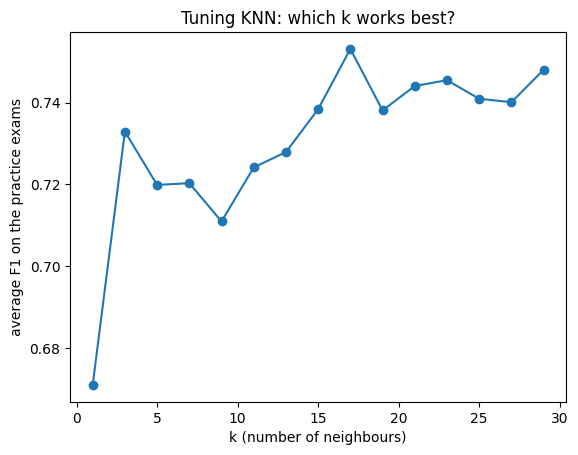

Best k: 17 with F1 0.753


In [16]:
# Step 6c — Tuning k with a plain for-loop + a plot
import matplotlib.pyplot as plt

k_values = list(range(1, 31, 2))
k_scores = []
for k in k_values:
    knn_pipeline.set_params(model__n_neighbors=k)     # "model__n_neighbors" = the n_neighbors of the step called "model"
    k_scores.append(cross_val_score(knn_pipeline, X_train, y_train, cv=practice_exams, scoring="f1").mean())

plt.plot(k_values, k_scores, marker="o")
plt.xlabel("k (number of neighbours)")
plt.ylabel("average F1 on the practice exams")
plt.title("Tuning KNN: which k works best?")
plt.show()

best = k_scores.index(max(k_scores))
print("Best k:", k_values[best], "with F1", round(k_scores[best], 3))

That loop is so common that scikit-learn has it built in: **`GridSearchCV`**. You give it a model and a *grid* — a dictionary of settings to try — and it runs every setting on the same practice exams and keeps the best one. We do it for all three models, each with its most important knob:

| Model | The knob | What it means |
|---|---|---|
| KNN | `n_neighbors` | how many neighbours vote |
| Logistic regression | `C` | how much it may bend towards the training data (small = cautious, big = eager) |
| Decision tree | `max_depth` | how many questions deep the tree may go (deep = memorising, remember overfitting) |

*(The same dictionary-in-a-loop you wrote in Week 3 — scikit-learn just does the looping.)*

In [17]:
# Step 6d — GridSearchCV: the loop, done for you, for all three models
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

candidates = {
    "KNN": (KNeighborsClassifier(), {"model__n_neighbors": list(range(1, 31, 2))}),
    "Logistic regression": (LogisticRegression(max_iter=1000), {"model__C": [0.01, 0.1, 1, 10, 100]}),
    "Decision tree": (DecisionTreeClassifier(random_state=42), {"model__max_depth": [1, 2, 3, 4, 5, 6, 8, 10, None]}),
}

tuned = {}
for name, (algorithm, grid) in candidates.items():
    search = GridSearchCV(Pipeline([("prep", prep), ("model", algorithm)]),
                          grid, cv=practice_exams, scoring="f1")
    search.fit(X_train, y_train)          # training data only — the envelope stays closed
    tuned[name] = search
    spread = search.cv_results_["std_test_score"][search.best_index_]
    print(name, "| best setting:", search.best_params_,
          "| practice-exam F1:", round(search.best_score_, 3), "+/-", round(spread, 3))

KNN | best setting: {'model__n_neighbors': 17} | practice-exam F1: 0.753 +/- 0.035
Logistic regression | best setting: {'model__C': 1} | practice-exam F1: 0.726 +/- 0.034
Decision tree | best setting: {'model__max_depth': 4} | practice-exam F1: 0.726 +/- 0.029


#### 🧩 Your turn 2 — tune the tree yourself
Do what step 6c did for KNN, but for the decision tree: loop over `max_depth` from 1 to 12, compute the average practice-exam F1 for each, and plot it. Where does it stop getting better? What happens to the **training** score as the tree gets deeper? *(Hint: `cross_validate(..., return_train_score=True)` from `sklearn.model_selection` works like `cross_val_score`, but gives you the training scores too: `result["test_score"]` and `result["train_score"]`.)*

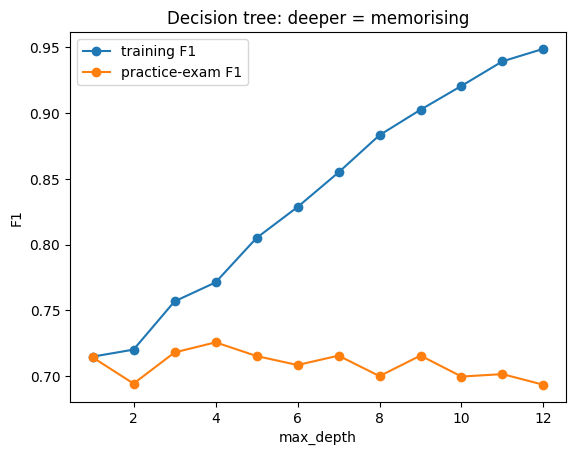

Best depth on the practice exams: 4 with F1 0.726
depth  1 | train 0.715 | practice 0.714 | gap 0.001
depth  2 | train 0.72 | practice 0.694 | gap 0.026
depth  3 | train 0.757 | practice 0.718 | gap 0.039
depth  4 | train 0.771 | practice 0.726 | gap 0.046
depth  5 | train 0.805 | practice 0.715 | gap 0.09
depth  6 | train 0.828 | practice 0.708 | gap 0.12
depth  7 | train 0.855 | practice 0.716 | gap 0.139
depth  8 | train 0.883 | practice 0.7 | gap 0.183
depth  9 | train 0.902 | practice 0.716 | gap 0.187
depth 10 | train 0.921 | practice 0.7 | gap 0.221
depth 11 | train 0.939 | practice 0.702 | gap 0.238
depth 12 | train 0.949 | practice 0.693 | gap 0.255


In [18]:
# Your turn 2 — tune the tree yourself
from sklearn.model_selection import cross_validate

depths = list(range(1, 13))
train_f1 = []
practice_f1 = []
for d in depths:
    tree_pipeline = Pipeline([("prep", prep), ("model", DecisionTreeClassifier(max_depth=d, random_state=42))])
    result = cross_validate(tree_pipeline, X_train, y_train, cv=practice_exams, scoring="f1", return_train_score=True)
    train_f1.append(result["train_score"].mean())
    practice_f1.append(result["test_score"].mean())

plt.plot(depths, train_f1, marker="o", label="training F1")
plt.plot(depths, practice_f1, marker="o", label="practice-exam F1")
plt.xlabel("max_depth"); plt.ylabel("F1"); plt.title("Decision tree: deeper = memorising")
plt.legend(); plt.show()

best_d = depths[practice_f1.index(max(practice_f1))]
print("Best depth on the practice exams:", best_d, "with F1", round(max(practice_f1), 3))
for d, tr, pr in zip(depths, train_f1, practice_f1):
    print("depth", str(d).rjust(2), "| train", round(tr, 3), "| practice", round(pr, 3), "| gap", round(tr - pr, 3))
# The training score keeps rising towards 1.0 as the tree gets deeper, while the practice score stops
# improving after a few levels and then drops: the extra depth is memorisation (overfitting), not learning.

---
### Step 7 — The final exam, once

Now — and only now — open the envelope. Every tuned model takes the test **once**, and we put everything in **one table**, with the lazy model as the first row. Three columns to compare:

- **train** — how well it does on data it has seen,
- **practice** — the cross-validation average from step 6,
- **test** — the final exam.

**How to read it:** a big gap between *train* and *practice/test* means overfitting. And if two models differ by less than the spread from step 6 (about ±0.03 here), that difference is **luck, not skill** — call it a tie. Never go back and re-tune after seeing the test score; that turns the exam into another practice round.

In [19]:
# Step 7 — Open the envelope: one comparison table
from sklearn.metrics import f1_score, precision_score

rows = [{"model": "Lazy model (baseline)", "best setting": "-", "train F1": 0.0, "practice F1": 0.0,
         "test F1": round(f1_score(y_test, lazy_predictions), 3),
         "test precision": 0.0, "test recall": round(recall_score(y_test, lazy_predictions), 3)}]

for name, search in tuned.items():
    model = search.best_estimator_
    test_predictions = model.predict(X_test)
    rows.append({
        "model": name,
        "best setting": str(search.best_params_).replace("model__", ""),
        "train F1": round(f1_score(y_train, model.predict(X_train)), 3),
        "practice F1": round(search.best_score_, 3),
        "test F1": round(f1_score(y_test, test_predictions), 3),
        "test precision": round(precision_score(y_test, test_predictions), 3),
        "test recall": round(recall_score(y_test, test_predictions), 3),
    })

comparison = pd.DataFrame(rows)
comparison

,model,best setting,train F1,practice F1,test F1,test precision,test recall
0,Lazy model (baseline),-,0.000,0.000,0.000,0.000,0.000
1,KNN,{'n_neighbors': 17},0.763,0.753,0.726,0.818,0.652
2,Logistic regression,{'C': 1},0.739,0.726,0.724,0.793,0.667
3,Decision tree,{'max_depth': 4},0.756,0.726,0.673,0.864,0.551


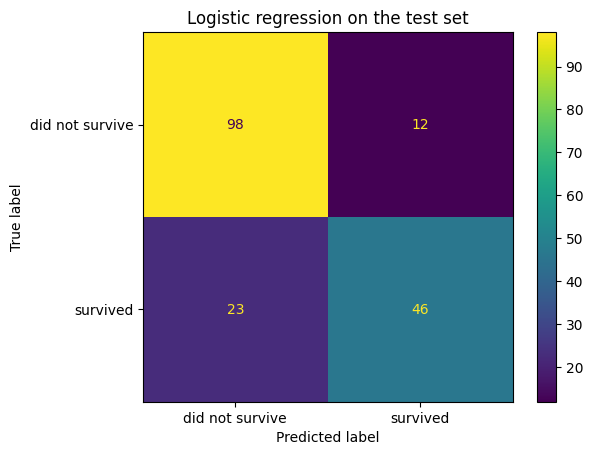

In [20]:
# The confusion matrix of the model we would pick
from sklearn.metrics import ConfusionMatrixDisplay

chosen = tuned["Logistic regression"].best_estimator_
ConfusionMatrixDisplay.from_estimator(chosen, X_test, y_test, display_labels=["did not survive", "survived"])
plt.title("Logistic regression on the test set")
plt.show()

**Which one would we recommend?** KNN, logistic regression and the tree are within each other's spread on the practice exams — a tie. When scores tie, pick on **other grounds**: logistic regression is fast, gives a probability, and you can *explain* it (every column gets a weight you can show). The tree is even easier to explain, but it misses more survivors (lowest recall). That reasoning — not just the highest number — is what a good recommendation looks like. *"None of them is good enough for this job"* is also an allowed answer, if you can say why.

---
### Step 8 — Check the groups, then use it

One average score can hide that a model works **great for one group and badly for another**. So split the test results per group and compare. Here: how many real survivors does the model find among women, and among men?

In [21]:
# Step 8a — Does it work equally well for everyone?
test_predictions = chosen.predict(X_test)

for group in ["female", "male"]:
    in_group = X_test["sex"] == group
    print(group, "| passengers:", in_group.sum(),
          "| real survival rate:", round(y_test[in_group].mean(), 2),
          "| recall (survivors found):", round(recall_score(y_test[in_group], test_predictions[in_group]), 2))

female | passengers: 61 | real survival rate: 0.74 | recall (survivors found): 0.96
male | passengers: 118 | real survival rate: 0.2 | recall (survivors found): 0.12


**Look at that gap.** The model finds almost every woman who survived, and barely any man who did. It has learned the rule of 1912 — *"women and children first"* — and turned it into *"women survive, men do not"*. That was roughly true on that night, but it means the model is nearly useless for the men who did survive.

This is what happens with every dataset: **the history inside the data becomes the model's rule.** If your Friday data comes from a world that treated some group unfairly, your model will learn that unfairness and repeat it — confidently. That is why you check the groups, and why you write down what you found.

#### 🧩 Your turn 3 — check another group
Do the same check per **passenger class** (`pclass` 1, 2 and 3). Who does the model serve worst? Why do you think that is?

In [22]:
# Your turn 3 — check another group: passenger class
for group in [1, 2, 3]:
    in_group = X_test["pclass"] == group
    print("class", group, "| passengers:", in_group.sum(),
          "| real survival rate:", round(y_test[in_group].mean(), 2),
          "| recall (survivors found):", round(recall_score(y_test[in_group], test_predictions[in_group]), 2))

# ANSWER: the model serves 3rd class worst. It finds only 50% of the 3rd-class survivors,
# against 68% in 1st and 85% in 2nd class. Only 24% of 3rd-class passengers survived, so the model has learned
# "3rd class = did not survive" and mostly says no. The 3rd-class survivors look like the ones who died,
# so it misses them. Same pattern as with men: the group that was treated worst in 1912 is also the group
# the model serves worst today.

class 1 | passengers: 45 | real survival rate: 0.56 | recall (survivors found): 0.68
class 2 | passengers: 34 | real survival rate: 0.59 | recall (survivors found): 0.85
class 3 | passengers: 100 | real survival rate: 0.24 | recall (survivors found): 0.5


Finally, **use it**. A model is only a product when someone can give it a new case and get an answer. `predict` gives the answer; `predict_proba` gives **how sure** the model is — always show that number to your user, because *"survived, 51 % sure"* is a very different message from *"survived, 95 % sure"*.

In [23]:
# Step 8b — A new passenger (made up). The Pipeline cleans it exactly like the training data.
new_passengers = pd.DataFrame([
    {"pclass": 3, "sex": "male",   "age": 25, "sibsp": 0, "parch": 0, "fare": 8.0,  "embarked": "S"},
    {"pclass": 1, "sex": "female", "age": 30, "sibsp": 0, "parch": 0, "fare": 80.0, "embarked": "C"},
])
answers = chosen.predict(new_passengers)
sure = chosen.predict_proba(new_passengers)[:, 1]     # column 1 = the chance of "survived"

for i in range(len(new_passengers)):
    print("Passenger", i + 1, "->", "survived" if answers[i] == 1 else "did not survive",
          "| chance of surviving:", round(sure[i] * 100), "%")

Passenger 1 -> did not survive | chance of surviving: 10 %
Passenger 2 -> survived | chance of surviving: 95 %


#### 🧩 Your turn 4 — put yourself on the Titanic
Make a row for yourself (pick a class and a fare you could afford) and one for someone you know. What does the model say, and how sure is it? Would you trust it? *(Missing an age or a port? Put `None` — the Pipeline fills it in.)*

In [24]:
# Your turn 4 — put yourself on the Titanic
# A student today could only afford a 3rd-class ticket (fare 8, like most 3rd-class passengers), travelling alone.
# Because the model leans so heavily on "sex", I ran the SAME person twice, once as male and once as female.
me_and_others = pd.DataFrame([
    {"pclass": 3, "sex": "male",   "age": 21, "sibsp": 0, "parch": 0, "fare": 8.0,  "embarked": "S"},
    {"pclass": 3, "sex": "female", "age": 21, "sibsp": 0, "parch": 0, "fare": 8.0,  "embarked": "S"},
    {"pclass": 1, "sex": "male",   "age": 50, "sibsp": 1, "parch": 1, "fare": 90.0, "embarked": "C"},  # a parent, 1st class
])
labels = ["Me, 3rd class, if male", "Me, 3rd class, if female", "A parent, 1st class, male"]
answers = chosen.predict(me_and_others)
sure = chosen.predict_proba(me_and_others)[:, 1]
for i in range(len(me_and_others)):
    print(labels[i].ljust(28), "->", "survived" if answers[i] == 1 else "did not survive",
          "| chance of surviving:", round(sure[i] * 100), "%")

# ANSWER: my 3rd-class student profile gets 11% (did not survive) as male and 64% (survived) as female,
# with everything else exactly the same. A 1st-class father only gets 33%. Sex changes the answer more than
# anything else about the person. I would not trust it: it doesn't know anything about me, only about
# who was allowed into the lifeboats in 1912. The probability is useful, though: 64% is close to a coin flip,
# and a user should see that it's not a confident "yes".

Me, 3rd class, if male       -> did not survive | chance of surviving: 11 %
Me, 3rd class, if female     -> survived | chance of surviving: 64 %
A parent, 1st class, male    -> did not survive | chance of surviving: 33 %


---
### ✅ The checklist for Friday — the ways to fail without noticing

- ☐ **I looked before I touched:** gaps, balance, weird values, duplicates, cheat columns — and I wrote down what I decided about each.
- ☐ **I split first**, with `stratify=y` and a `random_state`.
- ☐ **All cleaning is inside a Pipeline** — nothing is filled or scaled before the split.
- ☐ **I have a baseline** (the lazy model), and my models beat it.
- ☐ **I chose my scoreboard before training**, because of which mistake hurts people more.
- ☐ **I tuned with practice exams only**, the same ones for every model.
- ☐ **I opened the envelope once**, and I did not go back to re-tune.
- ☐ **I checked the groups** and wrote down who the model serves worst.
- ☐ **A new case goes in, an answer and a probability come out.**
- ☐ **Restart & Run All works** — from the raw file to the final table, without me fixing anything by hand.

#### ✍️ Reflection
**The Titanic model finds almost every surviving woman and almost no surviving man. If a model like this were used to decide who gets help first in a disaster today, what would go wrong — and at which step of the recipe could you have caught it?**

> The model learned the rule of 1912, "women and children first", plus "1st class first" (it finds 85% of surviving 2nd-class and 68% of 1st-class passengers but only 50% in 3rd class). In a disaster today it would send help to women and rich passengers first and **write off men and poor people**. My own test showed this: the same 21-year-old 3rd-class student gets **64%** as a woman and **11%** as a man. That isn't a prediction about who *needs* help. It repeats who *got* help in 1912, which was decided by social rules, not by need. A rescue team trusting the "95% sure" output would be automating an old injustice with confidence.
> You can catch this at **step 1** (look at who is in the data and what the label really means: survival reflects who was *allowed* in the lifeboats), at **step 5** (choose a scoreboard that cares about finding everyone who needs help), and above all at **step 8**: checking recall **per group** (sex and class) makes the gap impossible to miss. And a deeper lesson: this data shouldn't be used for this purpose at all, because past outcomes are not a fair guide for who deserves help.

---
### Before Friday

- **Run this section to the end** and do the four *Your turn* cells. On Friday you copy these cells into a new notebook and swap in your own data — steps 1 to 8, in this order.
- **Check your setup:** `import pandas, sklearn, matplotlib` must work in your editor (they come with Anaconda).
- **Friday:** your pair, the SDG, and a dataset you find yourself. The model is one line. The recipe is the job.